# 4 — Line fitting

Ajustement de profils de Voigt sur les raies alpha de carbone (Cα) empilées par intervalles de nombre quantique.

**Pipeline :**
1. Imports & paramètres graphiques
2. Paramètres utilisateur (source, raie, fichiers)
3. Chargement des données FITS
4. Extraction et pondération des transitions individuelles
5. Détermination des intervalles de stacking
6. Chargement des stacks pré-calculés
7. Définition des fonctions de fit (Voigt)
8. Ajustement de chaque stack — visualisation
9. Visualisation comparative des trois jeux de stacks
10. Statistiques sur les centres de raie
11. Visualisation des paramètres de fit en fonction de n
12. Export CSV des résultats

## 1. Imports

In [1]:
import sys
import os

# Ajout du répertoire commun contenant calcul, fitfunc, graphics
# sys.path management removed — install with: pip install -e .

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from astropy.io import fits
import astropy.units as u
from astropy.modeling.models import Voigt1D

from scipy.optimize import curve_fit
from scipy.stats import linregress

import pandas as pd
from tqdm import tqdm
import warnings

# Modules locaux
import spectral_tools.tools as tools
import spectral_tools.line_fitting as line_fitting
import spectral_tools.graphics as graphics

warnings.filterwarnings('ignore')

## 2. Paramètres graphiques

In [2]:
%matplotlib widget

# --- Police et taille ---
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family']      = 'serif'
matplotlib.rcParams['font.size']        = 17

# --- Tracés ---
matplotlib.rcParams['axes.linewidth']   = 2.5
matplotlib.rcParams['lines.linewidth']  = 1.7

# --- Axe x ---
matplotlib.rcParams['xtick.direction']    = 'in'
matplotlib.rcParams['xtick.labelsize']    = 13
matplotlib.rcParams['xtick.major.size']   = 5
matplotlib.rcParams['xtick.major.width']  = 1
matplotlib.rcParams['xtick.minor.size']   = 4.5
matplotlib.rcParams['xtick.minor.width']  = 1

# --- Axe y ---
matplotlib.rcParams['ytick.direction']    = 'in'
matplotlib.rcParams['ytick.labelsize']    = 13
matplotlib.rcParams['ytick.major.size']   = 4.5
matplotlib.rcParams['ytick.major.width']  = 1
matplotlib.rcParams['ytick.minor.size']   = 3.5
matplotlib.rcParams['ytick.minor.width']  = 1

## 3. Paramètres utilisateur

In [3]:
# --- Source et raie ---
# Options disponibles : 'TAU_A', 'TAUA_CLOUDS', 'TAUCLOUDS_HI'
source  = 'TAUA_CLOUDS'
myLine  = 'Calph'
off     = False          # True → utilise le spectre OFF-source

OFF = '_OFF' if off else ''

# --- Fichier de données principal ---
path      = f'alltime_files/alltime_{source}_{myLine}{OFF}.fits'

# --- Source de référence (TAU_A seul, sans les nuages) ---
source_0  = 'TAU_A'
path_0    = f'alltime_files/alltime_{source_0}_{myLine}.fits'

# --- Catalogue des raies radio-recombinaison ---
pathlines = '../../Codes/rrlines.csv'

# --- Couleur par défaut pour les tracés ---
couleur   = 'green'

## 4. Paramètres de traitement

In [4]:
# --- Fréquence de référence ---
velo_sys = 0       # vitesse systémique (km/s) : on empile autour de 0

# --- Rebinning ---
SLOT = 4           # facteur de rebinning spectral

# --- Stacking : intervalles de nombre quantique ---
# qi = [pas_bas_n, pas_milieu_n, pas_haut_n]
qi = [40, 20, 50]
n0 = 500           # borne inférieure de l'intervalle moyen
n1 = 730           # borne supérieure de l'intervalle moyen

# --- Extraction des transitions ---
width = 1000       # largeur de la fenêtre d'extraction (canaux)

# --- Facteur d'échelle (évite les très petits flottants) ---
OG = 1e4

## 5. Chargement des données FITS

In [5]:
# Ouverture du spectre principal et du spectre de référence
full_spectrum  = fits.open(path)
full_spectrum0 = fits.open(path_0)

# --- Fréquences min/max disponibles dans le fichier ---
fmini  = full_spectrum[0].header['FMIN']
fmaxi0 = full_spectrum[0].header['FMAX']

# Limitation à la voie 0 (LANE 0)
fmaxi = 47.55859375  # GHz — limite manuelle de la bande utile

# Récupération des transitions dans l'intervalle de fréquence
Lines = tools.get_line(fmini, fmaxi, velo_sys, line=myLine, path=pathlines)
lowest_n  = np.min(Lines.index)
highest_n = np.min((np.max(Lines.index), 850))  # on se limite à n=850

# --- Données spectrales ---
I   = full_spectrum[0].data[:, 0, 0]   # spectre d'intensité
RMS = full_spectrum[2].data[:, 0, 0]   # carte de bruit

# --- Axe fréquentiel ---
CRVAL = full_spectrum[0].header['CRVAL3']
CDELT = full_spectrum[0].header['CDELT3']
CRPIX = full_spectrum[0].header['CRPIX3']
NAXIS = full_spectrum[0].header['NAXIS3']
df    = CDELT   # résolution fréquentielle (GHz/canal)

f = np.array([CRVAL + (i - CRPIX) * CDELT for i in range(NAXIS)])

## 6. Extraction et pondération des transitions individuelles

In [6]:
isolated_lines    = []   # profils de raie extraits
quantum_numbers   = []   # nombres quantiques correspondants
weights_of_lines  = []   # poids de chaque raie (1/σ²)

# Fenêtre fréquentielle commune centrée sur chaque raie
slicefreq_window = np.linspace(-df * (width // 2), df * (width // 2), width)
FREF = np.copy(slicefreq_window)

# Seuil de S/N pour le plafonnement des poids
cap_calib   = True
val_max_snr = 6

for i in range(max(lowest_n, 426), min(highest_n, 850)):
    f0 = Lines.loc[i]
    if f0 < f[0] or f0 > f[-1]:
        continue

    slicedline = tools.slice_line(f0, I, f, cut_width=width // 2)

    # Correction brute : mise à zéro des canaux aberrants ou NaN
    slicedline[np.isnan(slicedline)]          = 0
    slicedline[np.abs(slicedline) > 100 / OG] = 0

    # Rejet si plus de 40 % des canaux sont nuls (transition contaminée)
    if len(slicedline[slicedline == 0]) / len(slicedline) > 0.4:
        isolated_lines.append(np.zeros(len(slicedline)) * np.nan)
        weights_of_lines.append(np.nan)
        continue

    slicedline[slicedline == 0] = np.nan
    isolated_lines.append(slicedline)
    quantum_numbers.append(i)

    # Calcul du bruit moyen sur la fenêtre
    slicedrms = np.nanmean(tools.slice_line(f0, RMS, f, cut_width=width // 2))

    if cap_calib:
        # Plafonnement : on veut S/N ≤ val_max_snr
        signal    = np.nanmin(slicedline)
        rms_min   = signal / val_max_snr
        slicedrms = max(slicedrms, rms_min)

    weights_of_lines.append(1 / slicedrms**2)

# Sauvegarde des versions originales
weights_of_lines_tot = np.copy(weights_of_lines)
isolated_lines_tot   = np.copy(isolated_lines)

## 7. Évaluation du S/N des transitions individuelles

In [7]:
# Calcul du rapport signal-sur-bruit pour identifier les transitions contaminées.
# Le signal est estimé au centre, le bruit sur les ailes.
SNRs_all  = []
Noise_all = []

for i in range(highest_n - lowest_n):
    line     = np.copy(isolated_lines[i])
    justline = line[width // 3 : 2 * width // 3]   # zone centrale (signal)
    Signal   = np.nanmean(justline)

    maskline = np.copy(line)
    maskline[width // 6 : 5 * width // 6] = np.nan  # masque la raie
    Noise    = np.nanstd(maskline)                   # bruit sur les ailes

    SNRs_all.append(-Signal / Noise)   # positif pour une raie en absorption
    Noise_all.append(Noise)

## 8. Définition des intervalles de stacking

In [8]:
# Les transitions sont regroupées en intervalles de nombre quantique n.
# On utilise trois pas différents selon la gamme de n :
#   - n < n0       : pas qi[0] (transitions larges, peu nombreuses)
#   - n0 ≤ n < n1  : pas qi[1]
#   - n ≥ n1       : pas qi[2]
dn = 1   # pas d'incrément pour le calcul des fréquences de raie

if isinstance(qi, list):
    quantum_intervals0 = [int(i) for i in range(lowest_n, n0 + qi[0], qi[0])]
    quantum_intervals1 = [int(i) for i in range(quantum_intervals0.pop(-1), n1 + qi[1], qi[1])]
    quantum_intervals2 = [int(i) for i in range(quantum_intervals1.pop(-1), highest_n + 1, qi[2])]
    quantum_intervals  = np.concatenate((quantum_intervals0, quantum_intervals1, quantum_intervals2))

nstacks           = len(quantum_intervals) - 1
quantum_intervals = np.array(quantum_intervals, dtype=int)

print(f'{nstacks} stacks définis sur n ∈ [{quantum_intervals[0]}, {quantum_intervals[-1]}]')
print('Bornes :', quantum_intervals)

13 stacks définis sur n ∈ [517, 837]
Bornes : [517 537 557 577 597 617 637 657 677 697 717 737 787 837]


## 9. Chargement des stacks pré-calculés

In [12]:
# Format des fichiers : colonnes [n_min, n_max, canal_0, canal_1, ...]
pathstack   = f'stacks/STACKS-{source}{OFF}.txt'
pathstack_0 = f'stacks/STACKS-{source_0}.txt'
pathstack_1 = f'stacks/STACKS-{source}.txt'

print('Fichier principal :', pathstack)

data     = np.loadtxt(pathstack)
qbounds  = data[:, :2]      # bornes [n_min, n_max] de chaque stack
STACKS   = data[:, 2:]      # profils empilés (source principale)
STACKS_0 = np.loadtxt(pathstack_0)[:, 2:]  # profils TAU_A seul
STACKS_1 = np.loadtxt(pathstack_1)[:, 2:]  # profils source complète
nstacks  = len(STACKS)

# Stacks résiduels : différence source_1 − source_0
#STACKS_res = STACKS_1 - STACKS_0

Fichier principal : stacks/STACKS-TAUA_CLOUDS.txt


## 10. Fonctions de fit Voigt

In [13]:
# Chaque profil est une somme de N composantes de Voigt.
# Les paramètres sont passés sous forme d'un vecteur plat :
#   args = [c0, a0, lw0, gw0,  c1, a1, lw1, gw1, ...]
# avec pour chaque composante :
#   c  : centre (en fréquence, GHz)
#   a  : amplitude
#   lw : largeur lorentzienne (GHz)
#   gw : largeur gaussienne   (GHz)


def helper(v, *args):
    """Profil multi-Voigt mis à l'échelle OG, pour curve_fit (retourne -voigt*OG)."""
    voigt = np.zeros(len(v))
    for kv in range(len(args) // 4):
        c0, a0, lw0, gw0 = args[4*kv : 4*(kv+1)]
        voigt += line_fitting.voigt(v, c0, a0, lw0, gw0)
    return -voigt * OG


def helperplot(v, *args):
    """Profil multi-Voigt normalisé, pour la visualisation (retourne -voigt)."""
    voigt = np.zeros(len(v))
    for kv in range(len(args) // 4):
        c0, a0, lw0, gw0 = args[4*kv : 4*(kv+1)]
        voigt += line_fitting.voigt(v, c0, a0, lw0, gw0)
    return -voigt


def fit_one_stack(k_stacks, rms=False, velos=[-15, 15], dvelos=15):
    """
    Ajuste un profil multi-Voigt sur le stack d'indice k_stacks.

    Paramètres
    ----------
    k_stacks : int
        Indice du stack dans STACKS.
    rms : bool
        Si True, utilise le bruit des ailes comme sigma pour curve_fit.
    velos : list of float
        Vitesses initiales des composantes (km/s).
    dvelos : float or list of float
        Demi-fenêtres de recherche autour de chaque vitesse (km/s).

    Retourne
    --------
    popt, pcov : tableaux des paramètres ajustés et de leur covariance.
    """
    nmin = quantum_intervals[k_stacks]
    nmax = quantum_intervals[k_stacks + 1]
    central_freq = tools.line_freq(0.5 * (nmin + nmax)).to(u.MHz).value

    # Rebinning du spectre
    Line0 = STACKS[k_stacks] * OG
    Line, xaxis = tools.rebinning(Line0, FREF, SLOT)

    # Estimation du bruit sur les ailes (exclut le tiers central)
    maskline = np.copy(Line)
    maskline[len(Line)//6 : 5*len(Line)//6] = np.nan
    Noise = np.nanstd(maskline) if rms else 1

    # Initialisation des bornes et paramètres initiaux
    bounds = np.zeros((2, 4 * len(velos)))
    p0     = np.zeros(4 * len(velos))

    for kv, v0 in enumerate(velos):
        dvelo = dvelos[kv] if hasattr(dvelos, '__len__') else dvelos

        # Borne sur le centre (converti en fréquence)
        bounds[0][4*kv] = -tools.v_to_f(v0 - dvelo, central_freq).value
        bounds[1][4*kv] = -tools.v_to_f(v0 + dvelo, central_freq).value
        p0[4*kv]        = -tools.v_to_f(v0,         central_freq).value

        # Amplitude (positive car on fit -voigt)
        bounds[0][4*kv+1] = OG / 100
        bounds[1][4*kv+1] = OG
        p0[4*kv+1]        = OG / 2

        # Largeurs lorentzienne et gaussienne — bornes dépendent de n
        lim_Hz = 200 if k_stacks < 18 else 400
        bounds[0][4*kv+2] = 0
        bounds[1][4*kv+2] = -tools.v_to_f(lim_Hz,     central_freq).value
        p0[4*kv+2]        = -tools.v_to_f(lim_Hz / 2, central_freq).value

        bounds[0][4*kv+3] = 0
        bounds[1][4*kv+3] = -tools.v_to_f(lim_Hz,     central_freq).value
        p0[4*kv+3]        = -tools.v_to_f(lim_Hz / 4, central_freq).value

    popt, pcov = curve_fit(
        helper, xaxis, Line,
        p0=p0, bounds=bounds,
        maxfev=10000, nan_policy='omit', sigma=Noise
    )

    if np.any(np.isnan(popt)):
        return np.zeros(4 * len(velos)), np.zeros((4 * len(velos), 4 * len(velos)))

    return popt, pcov


def fit_one_stack_res(k_stacks, rms=False, velos=[-15, 15], dvelos=15):
    """
    Comme fit_one_stack, mais appliqué au stack résiduel (STACKS_res).
    Les bornes sur les largeurs sont plus larges (500 km/s) pour couvrir
    les structures diffuses.
    """
    nmin = quantum_intervals[k_stacks]
    nmax = quantum_intervals[k_stacks + 1]
    central_freq = tools.line_freq(0.5 * (nmin + nmax)).to(u.MHz).value

    Line0 = STACKS_res[k_stacks] * OG
    Line, xaxis = tools.rebinning(Line0, FREF, SLOT)

    maskline = np.copy(Line)
    maskline[len(Line)//6 : 5*len(Line)//6] = np.nan
    Noise = np.nanstd(maskline) if rms else 1

    bounds = np.zeros((2, 4 * len(velos)))
    p0     = np.zeros(4 * len(velos))

    for kv, v0 in enumerate(velos):
        dvelo = dvelos[kv] if hasattr(dvelos, '__len__') else dvelos

        bounds[0][4*kv] = -tools.v_to_f(v0 - dvelo, central_freq).value
        bounds[1][4*kv] = -tools.v_to_f(v0 + dvelo, central_freq).value
        p0[4*kv]        = -tools.v_to_f(v0,         central_freq).value

        bounds[0][4*kv+1] = OG / 100
        bounds[1][4*kv+1] = OG
        p0[4*kv+1]        = OG / 2

        # Bornes élargies (500 km/s) indépendantes de k_stacks
        bounds[0][4*kv+2] = 0
        bounds[1][4*kv+2] = -tools.v_to_f(500, central_freq).value
        p0[4*kv+2]        = -tools.v_to_f(250, central_freq).value

        bounds[0][4*kv+3] = 0
        bounds[1][4*kv+3] = -tools.v_to_f(500, central_freq).value
        p0[4*kv+3]        = -tools.v_to_f(250, central_freq).value

    popt, pcov = curve_fit(
        helper, xaxis, Line,
        p0=p0, bounds=bounds,
        maxfev=10000, nan_policy='omit', sigma=Noise
    )

    if np.any(np.isnan(popt)):
        return np.zeros(4 * len(velos)), np.zeros((4 * len(velos), 4 * len(velos)))

    return popt, pcov

## 11. Visualisation comparative des trois jeux de stacks

Superposition pour chaque bin de n :
- **rouge** (−5) : source principale (`STACKS`)
- **orange** (0) : source complète (`STACKS_1`)
- **noir** (+5) : référence TAU_A seul (`STACKS_0`)

Les offsets verticaux (±5 × 10⁻⁴) facilitent la comparaison.

IndexError: index 12 is out of bounds for axis 0 with size 12

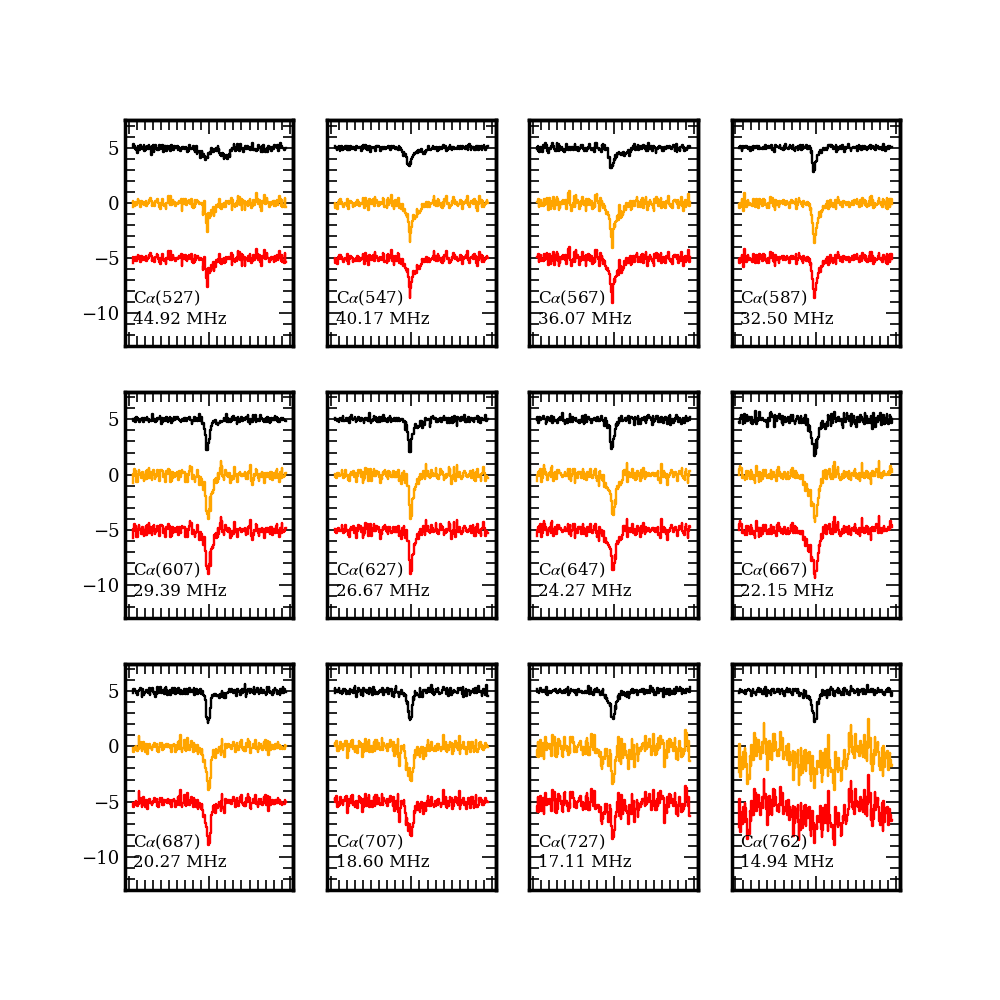

In [14]:
figs, axxs = plt.subplots(3, 4, figsize=(10, 10))

for ks in range(nstacks):
    nmin, nmax = qbounds[ks]
    N          = 0.5 * (nmin + nmax)
    ax         = axxs.flatten()[ks]
    ax.clear()

    central_freq = 0.5 * (tools.line_freq(nmin, dn) + tools.line_freq(nmax, dn)).to(u.MHz)

    for Line0, color, offset in [
        (STACKS[ks],   'red',    -5),
        (STACKS_1[ks], 'orange',  0),
        (STACKS_0[ks], 'black',  +5),
    ]:
        Line, xaxis = tools.rebinning(Line0, FREF, SLOT)
        ax.step(xaxis, Line * 1e4 + offset, c=color)

    ax.set_ylim(-13, 7.5)
    ax.text(0.05, 0.1,
            f"C$\\alpha$({int(N)})\n{central_freq:.2f}",
            transform=ax.transAxes, fontsize=12)
    graphics.set_axes(ax, pad=4)
    if ks % 4 > 0:
        ax.set_yticklabels([])
    if ks < 12:
        ax.set_xticklabels([])

figs.subplots_adjust(wspace=0, hspace=0)

## 12. Ajustement Voigt de chaque stack

Pour chaque bin, on ajuste une somme de profils de Voigt et on stocke :
- `CENT` : centres (km/s) et leurs incertitudes
- `WIDT` : largeurs FWHM (Hz) et leurs incertitudes
- `AREA` : aires intégrées (Hz) et leurs incertitudes

In [ ]:
couleur    = 'blue'
velos      = [0]        # composante unique centrée à 0 km/s
dvelo      = [20]       # demi-fenêtre de recherche (km/s)
linestyles = ['solid', 'dashed', 'dotted']

# Tableaux de résultats : (n_stacks-1) × (2 × n_composantes)
# Chaque paire de colonnes = [valeur, incertitude]
CENT = np.zeros((nstacks - 1, 2 * len(velos)))
AREA = np.zeros((nstacks - 1, 2 * len(velos)))
WIDT = np.zeros((nstacks - 1, 2 * len(velos)))
QUAN = np.zeros(nstacks - 1)   # nombre quantique moyen de chaque bin
CF   = []                       # fréquences centrales (MHz)

figs, axxs = plt.subplots(3, 4, figsize=(10, 10))

for ks in range(nstacks - 1):
    nmin, nmax   = qbounds[ks]
    N            = 0.5 * (nmin + nmax)
    QUAN[ks]     = N
    central_freq = 0.5 * (tools.line_freq(nmin, dn) + tools.line_freq(nmax, dn)).to(u.MHz)
    CF.append(central_freq.value)

    # Choix des vitesses initiales selon la gamme de n
    if N < 700:
        velos_eff  = [-v for v in velos]
        dveloeff   = dvelo
    else:
        velos_eff  = [-7]
        dveloeff   = 8

    popt, pcov = fit_one_stack(ks, rms=True, velos=velos_eff, dvelos=dveloeff)

    # Rebinning du spectre pour la visualisation
    Line, xaxis = tools.rebinning(STACKS[ks], FREF, SLOT)
    veloaxis    = xaxis

    ax = axxs.flatten()[ks]
    ax.clear()
    ax.step(veloaxis, Line * 1e4, c='gray')

    # Stockage temporaire des résultats pour ce bin
    wVs     = np.full(2 * len(velos), np.nan)
    Ifits   = np.full(2 * len(velos), np.nan)
    centers = np.full(2 * len(velos), np.nan)

    for kv in range(len(velos_eff)):
        c0,  a0,  lw0,  gw0  = popt[4*kv : 4*(kv+1)]
        dc0, da0, dlw0, dgw0 = np.sqrt(np.diag(pcov))[4*kv : 4*(kv+1)]

        y = helperplot(xaxis, c0, a0, lw0, gw0)
        ax.plot(veloaxis, y * 1e4, c=couleur, ls=linestyles[kv])

        # Largeur FWHM et son incertitude (Hz)
        wV  = line_fitting.voigt_fwhm(gw0, lw0)              * 1e6
        dwV = line_fitting.fwhm_voigt_err(dlw0, dgw0, lw0, gw0) * 1e6
        wVs[2*kv : 2*(kv+1)] = wV, dwV

        # Aire intégrée et son incertitude (Hz)
        Ifit  = np.nansum(-y) * (df * SLOT) * 1e6
        dIfit = Ifit * (dwV / wV)
        Ifits[2*kv : 2*(kv+1)] = Ifit, dIfit

        # Centre en vitesse et son incertitude (km/s)
        center  =  tools.f_to_v(c0,  central_freq.value).to(u.km/u.s).value
        dcenter = -tools.f_to_v(dc0, central_freq.value).to(u.km/u.s).value
        centers[2*kv : 2*(kv+1)] = center, dcenter

    WIDT[ks] = wVs
    AREA[ks] = Ifits
    CENT[ks] = centers

    ax.set_xlim(0.04, -0.04)
    ax.set_ylim(-7, 1.5)
    ax.text(0.05, 0.1,
            f"C$\\alpha$({int(N)})\n{central_freq:.2f}",
            transform=ax.transAxes, fontsize=12)
    graphics.set_axes(ax, pad=4)
    if ks % 4 > 0:
        ax.set_yticklabels([])
    if ks < 12:
        ax.set_xticklabels([])

# Masquage des fits non convergés (aire nulle)
mask = AREA < 1e-8
WIDT[mask] = np.nan
CENT[mask] = np.nan
AREA[mask] = np.nan

figs.subplots_adjust(wspace=0, hspace=0)
figs.supxlabel(r'Doppler shift $f - f_{n+1 \longrightarrow n}$')
figs.supylabel(r'$\tau \times 10^{-4}$')
figs.savefig('Beam-1-lines.pdf')

## 13. Distribution des centres de raie

Histogramme des centres ajustés (km/s) pour la première composante.

NameError: name 'CENT' is not defined

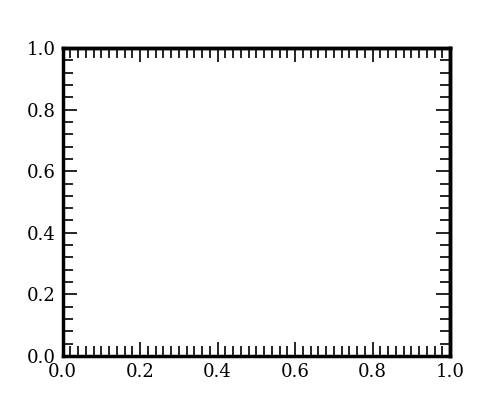

In [15]:
kv = 0
bins = np.arange(-12, 12, 1)

ficenter, axcenter = plt.subplots(figsize=(5, 4))
graphics.set_axes(axcenter, pad=5)

axcenter.hist(CENT[:, 2*kv], color=couleur, bins=bins)
axcenter.set_xlabel('Centre (km/s)')
axcenter.set_ylabel('Nombre de solutions')
ficenter.tight_layout()
ficenter.savefig('beam2center.pdf')

## 14. Moyenne pondérée des centres

In [ ]:
# weighted_avg_and_std moved to spectral_tools.tools
from spectral_tools.tools import weighted_avg_and_std


kv      = 0
weights = 1 / CENT[:, 2*kv+1]**2

# Moyenne pondérée en ignorant les NaN
center_masked = np.ma.masked_array(CENT[:, 2*kv], np.isnan(CENT[:, 2*kv]))
mean_weighted = np.ma.average(center_masked, weights=weights)
mean_w, std_w = weighted_avg_and_std(CENT[:, 2*kv], weights)

print(f'Moyenne pondérée : {mean_w:.2f} km/s')
print(f'Écart-type pondéré : {std_w:.2f} km/s')

## 15. Paramètres de fit en fonction du nombre quantique n

Trois panneaux : centres (km/s), largeurs FWHM (Hz), aires intégrées (Hz).

In [ ]:
XERR = (qbounds[:-1, 1] - qbounds[:-1, 0]) / 2
fmts = ['.', 's', '^']

figc, sbplot = plt.subplots(len(velos), 3, figsize=(12, 4 * len(velos)))

# Gestion de la forme selon le nombre de composantes
if len(velos) == 1:
    axcs, axws, axas = sbplot   # sbplot est 1D si une seule ligne
else:
    axcs, axws, axas = sbplot.T

for kv in range(len(velos)):
    axc = axcs if len(velos) == 1 else axcs[kv]
    axw = axws if len(velos) == 1 else axws[kv]
    axa = axas if len(velos) == 1 else axas[kv]

    for ax in [axc, axw, axa]:
        ax.clear()
        graphics.set_axes(ax, pad=5)

    # Centres
    axc.errorbar(QUAN, CENT[:, 2*kv], yerr=CENT[:, 2*kv+1], xerr=XERR,
                 fmt='.', color=couleur)
    axc.set_title('Centres (km/s)')
    axc.set_xlim(400, 850)
    axc.set_ylim(-75, 102)

    # Largeurs (échelle log)
    axw.semilogy()
    axw.errorbar(QUAN, WIDT[:, 2*kv], yerr=WIDT[:, 2*kv+1], xerr=XERR,
                 fmt=fmts[kv], c=couleur)
    axw.set_title('Largeurs FWHM (Hz)')
    axw.set_xlim(400, 850)
    axw.set_ylim(5e2, 1e5)

    # Aires
    axa.errorbar(QUAN, AREA[:, 2*kv], yerr=AREA[:, 2*kv+1], xerr=XERR,
                 fmt=fmts[kv], c=couleur)
    axa.set_title('Aires intégrées (Hz)')
    axa.set_xlim(400, 850)
    axa.set_ylim(-1, 4)

figc.suptitle(source + OFF)
figc.tight_layout()

## 16. Export des résultats en CSV

Un fichier par composante, nommé `fitresults/new/values_of_fit-<source>-<N>comp[-<kv>]-new.csv`.

In [ ]:
Q = np.array([QUAN]).T

for kv in range(len(velos)):
    # Assemblage du DataFrame ordonné par n
    df_out = pd.DataFrame(
        np.concatenate((
            Q,
            WIDT[:, 2*kv : 2*(kv+1)],
            AREA[:, 2*kv : 2*(kv+1)],
            CENT[:, 2*kv : 2*(kv+1)],
        ), axis=1),
        columns=['n', 'wV', 'dwV', 'Ifit', 'dIfit', 'CENTER', 'CENTER_err']
    ).sort_values('n')

    # Suffixe de composante (uniquement si multi-composantes)
    kvstr = f'-{kv}' if len(velos) > 1 else ''
    outpath = f'fitresults/new/values_of_fit-{source}{OFF}-{len(velos)}comp{kvstr}-new.csv'

    df_out.to_csv(outpath, index=False)
    print(f'Sauvegardé : {outpath}')